# Fase 3 -  Análisis Exploratorio de Datos (EDA) — Beijing PM2.5

## Descripción del problema

Este notebook realiza un **Análisis Exploratorio de Datos (EDA)** sobre el dataset *Beijing PM2.5 Data Set* del repositorio UCI Machine Learning Repository:

🔗 https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

### Contexto

El dataset contiene mediciones **horarias** de la concentración de partículas finas **PM2.5** (material particulado de diámetro ≤ 2.5 µm) registradas en la **Embajada de Estados Unidos en Beijing**, junto con datos meteorológicos del aeropuerto internacional capital de Beijing. El periodo cubierto es del **1 de enero de 2010 al 31 de diciembre de 2014** (5 años, ~43,824 registros).

Las partículas PM2.5 son uno de los principales indicadores de calidad del aire y están directamente asociadas con problemas respiratorios y cardiovasculares en la población. Predecir su concentración a partir de variables meteorológicas es un problema clásico de regresión / series temporales.

### Variables del dataset

| Columna | Descripción | Tipo |
|---|---|---|
| `No` | Número de fila | int |
| `year` | Año (2010–2014) | int |
| `month` | Mes (1–12) | int |
| `day` | Día del mes | int |
| `hour` | Hora (0–23) | int |
| `pm2.5` | Concentración de PM2.5 (µg/m³) — **variable objetivo** | float |
| `DEWP` | Punto de rocío (°C) | int |
| `TEMP` | Temperatura (°C) | int |
| `PRES` | Presión atmosférica (hPa) | int |
| `cbwd` | Dirección del viento combinada (NE, NW, SE, cv) | categórica |
| `Iws` | Velocidad acumulada del viento (m/s) | float |
| `Is` | Horas acumuladas de nieve | int |
| `Ir` | Horas acumuladas de lluvia | int |

## Objetivo del EDA

Este EDA es el paso previo a entrenar un modelo de **Machine Learning / Deep Learning** (típicamente regresión sobre `pm2.5`). Cubre:

1. Carga e inspección inicial de los datos.
2. Diagnóstico de calidad: nulos, duplicados, tipos.
3. Estadísticas descriptivas.
4. Análisis univariado (distribuciones).
5. Análisis bivariado (correlaciones, target vs features).
6. Análisis temporal (estacionalidad anual, mensual, horaria).
7. Detección de outliers.
8. Conclusiones y recomendaciones para la fase de modelado.

## 1. Carga e inspección



### Configuración del entorno de análisis

En esta sección se importan las librerías necesarias para el análisis exploratorio y visualización de datos. Se configuran parámetros globales de matplotlib y seaborn para asegurar que los gráficos tengan un formato consistente y legible a lo largo del notebook. Además, se ajustan las opciones de visualización de pandas para facilitar la inspección de grandes conjuntos de datos. Estos parámetros de configuración inicial establecen las preferencias estéticas y funcionales que se mantendrán en todo el análisis.



In [12]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Configuración global de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Mostrar más columnas/filas en pandas al imprimir
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# Reproducibilidad
#np.random.seed(42)


### Carga de datos e inspección inicial

Se especifica la ruta del archivo CSV que contiene el dataset de calidad del aire. Luego se carga el archivo utilizando pandas y se imprime un resumen rápido con el número total de filas y columnas, permitiendo verificar que los datos se cargaron correctamente.

In [13]:
# Ruta al archivo (ajusta si lo tienes en otra ubicación)
RUTA_CSV = r"../data/raw_dataset/PRSA_data_2010.1.1-2014.12.31.csv"

# Cargar el CSV
df = pd.read_csv(RUTA_CSV)

# Confirmación rápida
print(f"Dataset cargado. Forma: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado. Forma: 43,824 filas × 13 columnas


### Visualización de las primeras filas

Se muestra las primeras y ultimas 5 filas del dataset para inspeccionar la estructura de los datos, los nombres de las columnas y los tipos de valores presentes. Esto permite obtener una vista rápida de cómo está organizado el dataset.



In [14]:
# Primeras 5 filas
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [15]:
# Últimas 5 filas (verificar que el dataset termina como se espera)
df.tail()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0
43823,43824,2014,12,31,23,12.0,-21,-3.0,1034.0,NW,249.85,0,0


In [16]:
# Información general: tipos, nulos, memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


**Descripción del resultado:**

El dataset contiene 13 columnas con información meteorológica y de calidad del aire. Se observa que los datos comienzan en enero de 2010 y terminan en diciembre de 2014 (5 años de registro) con registros horarios. Las columnas incluyen variables como temperatura (TEMP), punto de rocío (DEWP), presión (PRES), dirección del viento (cbwd), velocidad del viento (Iws) y concentración de PM2.5 (variable objetivo).

### Preparación del índice temporal
Se construye una columna datetime combinando las columnas de año, mes, día y hora para crear marcas de tiempo completas. Se elimina la columna No ya que solo contiene índices de fila sin valor analítico. Posteriormente, se establece datetime como índice del DataFrame y se ordena cronológicamente.


In [17]:
# Construir la columna datetime a partir de year/month/day/hour
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

# Descartar la columna 'No' (es solo un id de fila, no aporta información)
df = df.drop(columns=["No"])

# Establecer el índice temporal y ordenar por si acaso
df = df.set_index("datetime").sort_index()

print(f"Rango temporal: {df.index.min()} → {df.index.max()}")
print(f"Frecuencia esperada: horaria (1H)")
print(f"Total de horas en el rango: {(df.index.max() - df.index.min()).total_seconds() / 3600 + 1:,.0f}")
print(f"Filas en el dataset:        {len(df):,}")
df.head()

Rango temporal: 2010-01-01 00:00:00 → 2014-12-31 23:00:00
Frecuencia esperada: horaria (1H)
Total de horas en el rango: 43,824
Filas en el dataset:        43,824


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
datetime,,,,,,,,,,,,
2010-01-01 00:00:00,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01 01:00:00,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01 02:00:00,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
2010-01-01 03:00:00,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
2010-01-01 04:00:00,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


**Descripción del resultado:**

El resultado anterior nos permite confirmar que la fila de fechas no presenta datos faltantes, es decir, el paso de tiempo es uniforme y con una fecuencia horaria.

## 2. Análisis de Calidad de los datos



### Valores nulos

El campo `pm2.5` es notorio en este dataset por tener una cantidad importante de nulos (la estación no registró durante varias horas). Hay que cuantificarlos antes de decidir cómo tratarlos.

Se realiza un análisis exhaustivo de los valores nulos en el dataset, comenzando con un resumen tabular que cuantifica la cantidad y porcentaje de faltantes por columna. Posteriormente, se visualiza la distribución temporal de datos faltantes de PM2.5 en tres niveles de agregación: diaria, mensual y anual, permitiendo identificar patrones estacionales o temporales en la ausencia de datos.

A continuación, se analiza la estructura de los datos faltantes mediante la identificación de secuencias consecutivas de valores nulos. Este análisis es crítico para elegir la estrategia de imputación adecuada: secuencias cortas (horas/días) pueden ser imputadas mediante interpolación, mientras que secuencias largas (meses) podrían requerir métodos más sofisticados o exclusión de datos.

El histograma resultante muestra la frecuencia de diferentes longitudes de secuencias faltantes, revelando si los datos ausentes son aislados o forman períodos extensos de discontinuidad.

In [18]:
# Cantidad y porcentaje de nulos por columna
nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "% nulos": (df.isnull().sum() / len(df) * 100).round(2)
})
nulos.sort_values("nulos", ascending=False)

,nulos,% nulos
pm2.5,2067,4.72
year,0,0.00
day,0,0.00
month,0,0.00
hour,0,0.00
DEWP,0,0.00
TEMP,0,0.00
PRES,0,0.00
cbwd,0,0.00
Iws,0,0.00


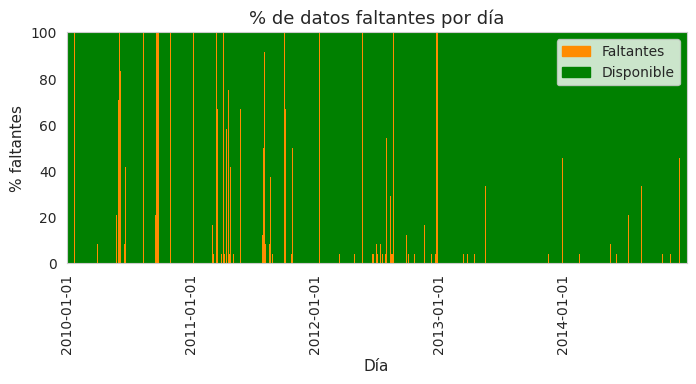

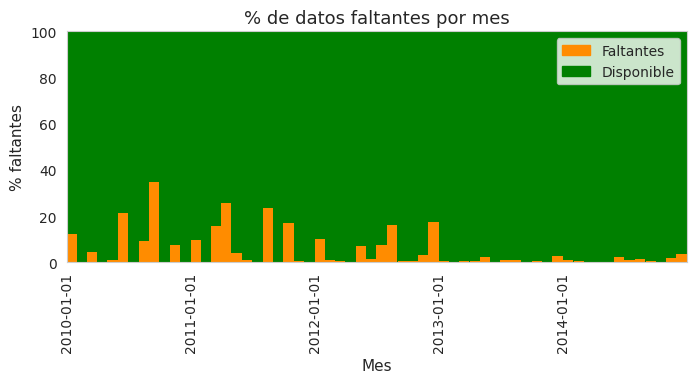

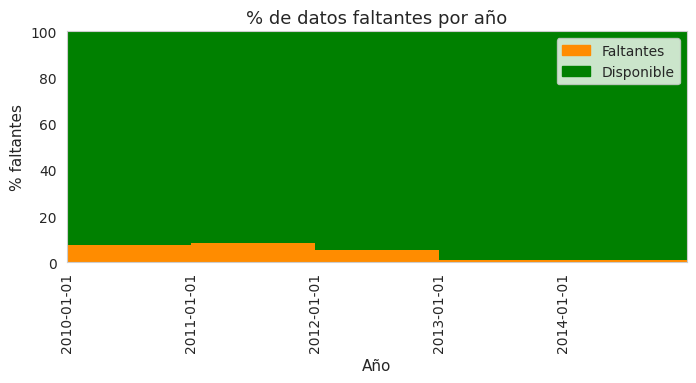

In [22]:
# Visualizar dónde están los nulos de pm2.5 a lo largo del tiempo
# Si están concentrados en periodos específicos o son aleatorios, eso afecta la estrategia de imputación


missing_daily = df['pm2.5'].isnull().resample('D').mean() * 100
missing_monthly = df['pm2.5'].isnull().resample('MS').mean() * 100
missing_yearly = df['pm2.5'].isnull().resample('YS').mean() * 100
years = pd.date_range('2010-01-01', '2014-12-31', freq='YS')
faltantes_patch = mpatches.Patch(color='darkorange', label='Faltantes')
disponible_patch = mpatches.Patch(color='green', label='Disponible')


# Porcentaje de faltantes por día
plt.figure(figsize=(8, 3))
plt.bar(missing_daily.index, missing_daily.values, color='darkorange', width = 1, label='Faltantes', align='edge', edgecolor='none')
plt.title('% de datos faltantes por día')
plt.ylim(0,100)
plt.xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2014-12-31'))
plt.xticks(years, [y.strftime('%Y-%m-%d') for y in years], rotation=90)
plt.ylabel('% faltantes')
plt.xlabel('Día')
plt.gca().set_facecolor('green')
plt.gca().grid(False)
plt.legend(handles=[faltantes_patch, disponible_patch], loc='upper right')
plt.show()

# Porcentaje de faltantes por mes
plt.figure(figsize=(8, 3))
plt.bar(missing_monthly.index, missing_monthly.values, color='darkorange', width = 30, label='Faltantes', align='edge', edgecolor='none')
plt.ylim(0,100)
plt.xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2014-12-31'))
plt.xticks(years, [y.strftime('%Y-%m-%d') for y in years], rotation=90)
plt.title('% de datos faltantes por mes')
plt.ylabel('% faltantes')
plt.xlabel('Mes')
plt.gca().set_facecolor('green')
plt.gca().grid(False)
plt.legend(handles=[faltantes_patch, disponible_patch], loc='upper right')
plt.show()

# Porcentaje de faltantes por año
plt.figure(figsize=(8, 3))
plt.bar(missing_yearly.index, missing_yearly.values, color='darkorange', width = 366, label='Faltantes', align='edge', edgecolor='none')
plt.ylim(0,100)
plt.xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2014-12-31'))
plt.xticks(years, [y.strftime('%Y-%m-%d') for y in years], rotation=90)
plt.title('% de datos faltantes por año')
plt.ylabel('% faltantes')
plt.xlabel('Año')
plt.gca().set_facecolor('green')
plt.gca().grid(False)
plt.legend(handles=[faltantes_patch, disponible_patch], loc='upper right')
plt.show()

Conteo de secuencias de datos erróneos consecutivos:
1 consecutivos -  0d 1h - 112 veces
2 consecutivos -  0d 2h - 29 veces
3 consecutivos -  0d 3h - 2 veces
4 consecutivos -  0d 4h - 5 veces
5 consecutivos -  0d 5h - 6 veces
6 consecutivos -  0d 6h - 4 veces
7 consecutivos -  0d 7h - 6 veces
8 consecutivos -  0d 8h - 3 veces
9 consecutivos -  0d 9h - 6 veces
10 consecutivos -  0d 10h - 3 veces
11 consecutivos -  0d 11h - 1 veces
12 consecutivos -  0d 12h - 2 veces
14 consecutivos -  0d 14h - 2 veces
16 consecutivos -  0d 16h - 2 veces
17 consecutivos -  0d 17h - 2 veces
19 consecutivos -  0d 19h - 2 veces
20 consecutivos -  0d 20h - 1 veces
22 consecutivos -  0d 22h - 2 veces
23 consecutivos -  0d 23h - 1 veces
24 consecutivos -  1d 0h - 3 veces
29 consecutivos -  1d 5h - 2 veces
37 consecutivos -  1d 13h - 1 veces
40 consecutivos -  1d 16h - 1 veces
42 consecutivos -  1d 18h - 1 veces
44 consecutivos -  1d 20h - 1 veces
48 consecutivos -  2d 0h - 1 veces
52 consecutivos -  2d 4h - 1 

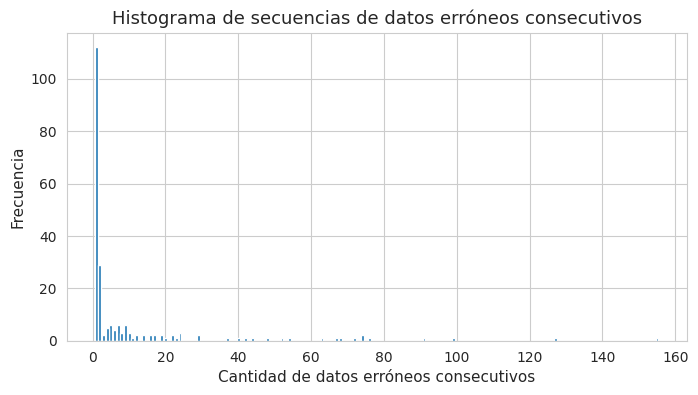

In [23]:
# Conteo de faltantes
is_nan = df['pm2.5'].isna().astype(int)

# Encontrar las longitudes de las secuencias de datos erróneos consecutivos
bad_lengths = []
count = 0
for val in is_nan:
    if val == 1:
        count += 1
    elif count > 0:
        bad_lengths.append(count)
        count = 0
if count > 0:
    bad_lengths.append(count)

# Contar cuántas secuencias hay de cada longitud
from collections import Counter
length_counts = Counter(bad_lengths)



# Mostrar el conteo
print("Conteo de secuencias de datos erróneos consecutivos:")
for length, cnt in sorted(length_counts.items()):
    td = pd.Timedelta(hours=length)
    print(f"{length} consecutivos -  {td.days}d {td.seconds // 3600}h - {cnt} veces")

# Graficar histograma
plt.figure(figsize=(8,4))
plt.bar(length_counts.keys(), length_counts.values())
plt.xlabel('Cantidad de datos erróneos consecutivos')
plt.ylabel('Frecuencia')
plt.title('Histograma de secuencias de datos erróneos consecutivos')
plt.show()

**Descripción del resultado:**

**Completitud del dataset:** l dataset contiene 43,824 registros con excelente integridad. Solo la variable PM2.5 presenta faltantes (2,067 valores, 4.72%), mientras que todas las demás variables (temporales y meteorológicas) están completas sin duplicados.

**Estructura de la secuencia de faltantes:** Los 2,067 valores nulos de PM2.5 forman secuencias de diferentes longitudes. La mayoría son muy cortas: 112 eventos de 1 hora consecutiva, 29 de 2 horas, y disminuyendo progresivamente. Solo 9 secuencias superan 2 días, con la máxima de 155 horas consecutivas (6.11 días).

**Estrategia de imputación:**

- **Secuencias de 1 hora:** Se imputarán mediante interpolación lineal, aprovechando que el cambio en PM2.5 es generalmente suave entre horas consecutivas.
- **Secuencias más largas (2+ días):** Se eliminarán del dataset, ya que períodos extensos de faltantes representan incertidumbre demasiado grande que podría comprometer la calidad del modelo predictivo.

Esta estrategia conservadora preserva la integridad de los datos de entrenamiento mientras recupera la máxima cantidad de información disponible y es consecuente debido a que el porcentaje de datos faltantes es bajo.

### Revisión de duplicados

Verificamos también si hay timestamps duplicados (no debería haberlos en un dataset horario bien formado).

In [ ]:
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
print(f"Timestamps duplicados:    {df.index.duplicated().sum()}")
# No hay! genial

Filas duplicadas exactas: 0
Timestamps duplicados:    0


## 3. Estadística descriptiva



### Análisis de las variables numéricas y categóricas

Se presenta un resumen estadístico de todas las variables numéricas del dataset, incluyendo medidas de tendencia central (media, mediana) y dispersión (desviación estándar, mínimo, máximo, percentiles). Esto permite identificar rangos, valores atípicos potenciales y el comportamiento general de cada variable.

Para la variable categórica cbwd (dirección del viento), se visualiza su distribución de frecuencias en lugar de estadísticas descriptivas, ya que representa categorías (NE=Noreste, NW=Noroeste, SE=Sureste, cv=Calma/Variable) cuya importancia radica en su prevalencia relativa. Esta información es crítica porque la dirección del viento influye significativamente en la dispersión y concentración de contaminantes, afectando directamente los niveles de PM2.5 observados.

In [13]:
# Estadísticas de variables numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,43824.0,2012.00,1.41,2010.00,2011.00,2012.00,2013.00,2014.0
month,43824.0,6.52,3.45,1.00,4.00,7.00,10.00,12.0
day,43824.0,15.73,8.80,1.00,8.00,16.00,23.00,31.0
hour,43824.0,11.50,6.92,0.00,5.75,11.50,17.25,23.0
pm2.5,41757.0,98.61,92.05,0.00,29.00,72.00,137.00,994.0
DEWP,43824.0,1.82,14.43,-40.00,-10.00,2.00,15.00,28.0
TEMP,43824.0,12.45,12.20,-19.00,2.00,14.00,23.00,42.0
PRES,43824.0,1016.45,10.27,991.00,1008.00,1016.00,1025.00,1046.0
Iws,43824.0,23.89,50.01,0.45,1.79,5.37,21.91,585.6
Is,43824.0,0.05,0.76,0.00,0.00,0.00,0.00,27.0


In [ ]:
# Como hay viento...esta es mejor verla con la frecuencia de la variable... 
# Frecuencia de la variable categórica 'cbwd' (dirección del viento)
# NE = noreste, NW = noroeste, SE = sureste, cv = calm/variable
df["cbwd"].value_counts(dropna=False)

cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

**Caracterización del Dataset de Calidad del Aire**

**Cobertura temporal:** El dataset abarca 5 años completos (2010-2014) con 43,824 registros horarios distribuidos uniformemente. La media anual es 2012 (año central), confirmando cobertura balanceada, aunque PM2.5 tiene 2,067 registros faltantes, resultando en 41,757 observaciones válidas.

**Contaminación por PM2.5:** La concentración promedio es 98.61 µg/m³ con alta variabilidad (std=92.05). El percentil 50 (72 µg/m³) está por debajo de la media, indicando distribución sesgada con eventos extremos de contaminación (máximo=994 µg/m³). El primer cuartil (29 µg/m³) representa días relativamente limpios, mientras valores superiores a 137 µg/m³ indican episodios contaminantes.

**Condiciones meteorológicas:**

- **Temperatura:** Promedio 12.45°C con rango entre -19°C y 42°C, reflejando clima continental con variaciones estacionales.
- **Punto de rocío:** Media 1.82°C (std=14.43), indicando variabilidad en humedad.
- **Presión:** Muy estable alrededor de 1016.45 hPa (std=10.27), normal en condiciones típicas.
- **Velocidad del viento (Iws):** Media 23.89 m/s pero distribución muy asimétrica (std=50.01), con mediana 5.37 m/s, sugiriendo días con calmas frecuentes y ocasionales eventos de viento intenso (máximo=585.6 m/s, posible error).
- **Nieve acumulada (Is):** Predominantemente ausente (media=0.05, mediana=0), con máximo de 27 horas, indicando eventos nevados ocasionales durante invierno.
- **Lluvia acumulada (Ir):** Igualmente baja (media=0.19, mediana=0), con máximo de 36 horas, reflejando clima semiárido con precipitaciones esporádicas.
- **Dirección del viento:** SE y NW son dominantes (15,290 y 14,150 eventos respectivamente), representando el 70% de las observaciones. cv (calmas/variable) ocupa 21.4% (9,387 eventos), crítico para interpretación de contaminación. NE es menos frecuente (11.4%).

## 4. Análisis univariado



Identificar distribución de cada variable individualmente. Los features son simétricos?, sesgados?, multimodales?, o si tienen colas largas — esto todo es para ver... que transformaciones son mejores antes de ingresar las variables a un modelo.

Se visualizan las distribuciones de frecuencia de todas las variables numéricas mediante histogramas. Este análisis es fundamental para identificar la forma de cada distribución (normal, sesgada, multimodal) y detectar anomalías.


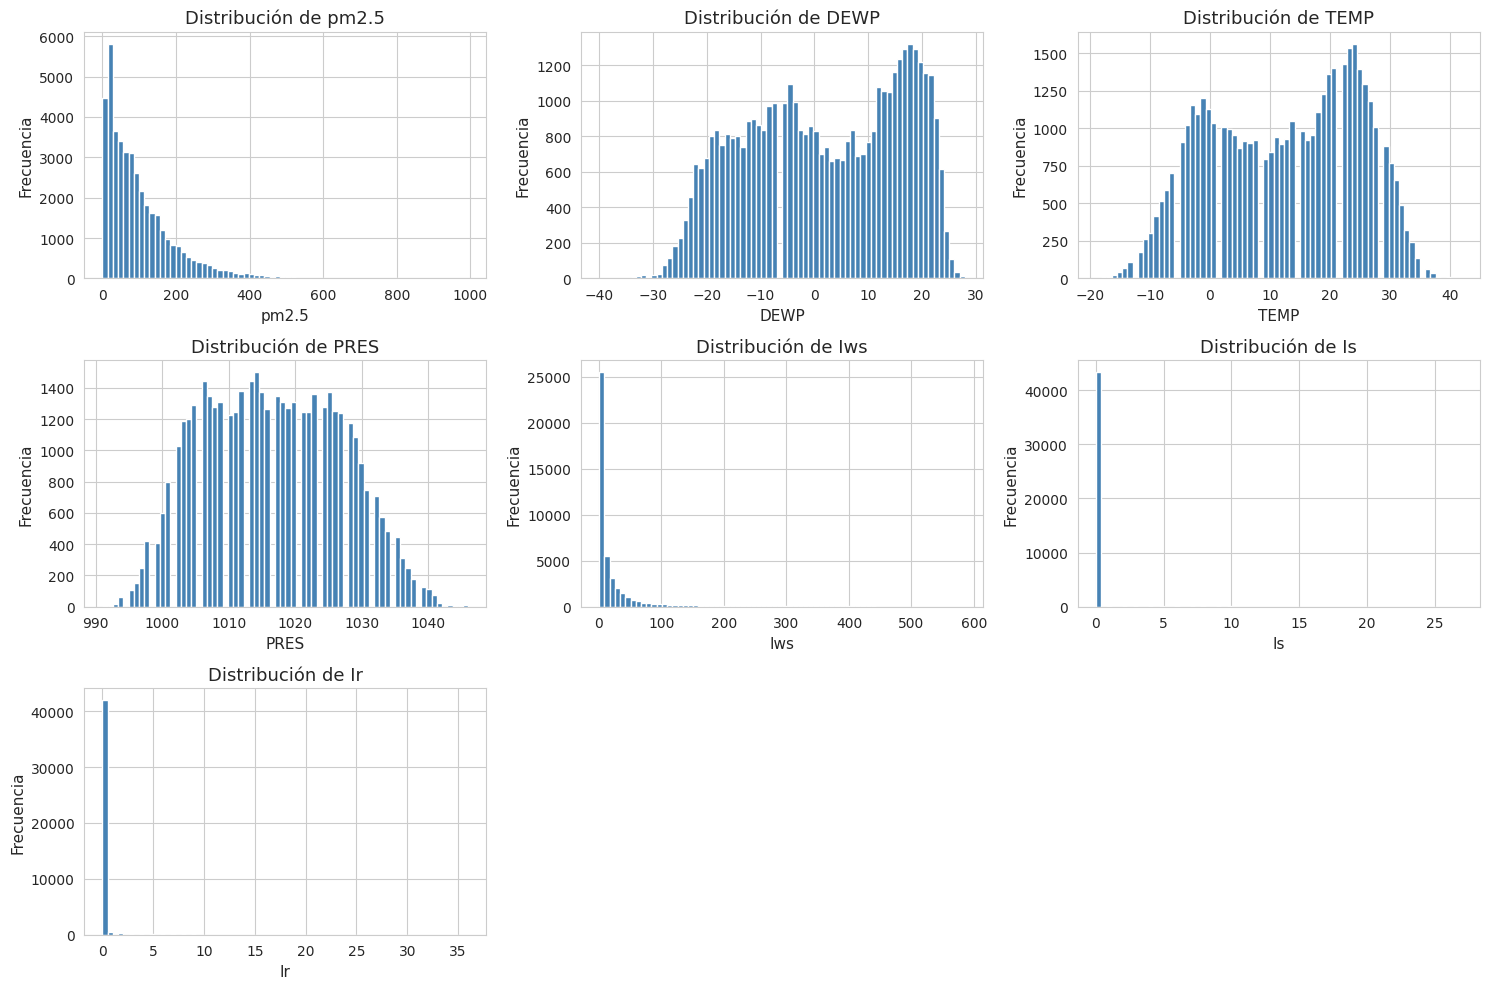

In [32]:
# Histogramas de todas las variables numéricas
variables_numericas = ["pm2.5", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    axes[i].hist(df[col].dropna(), bins=70, color="steelblue", edgecolor="white")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Ocultar los ejes sobrantes
for j in range(len(variables_numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

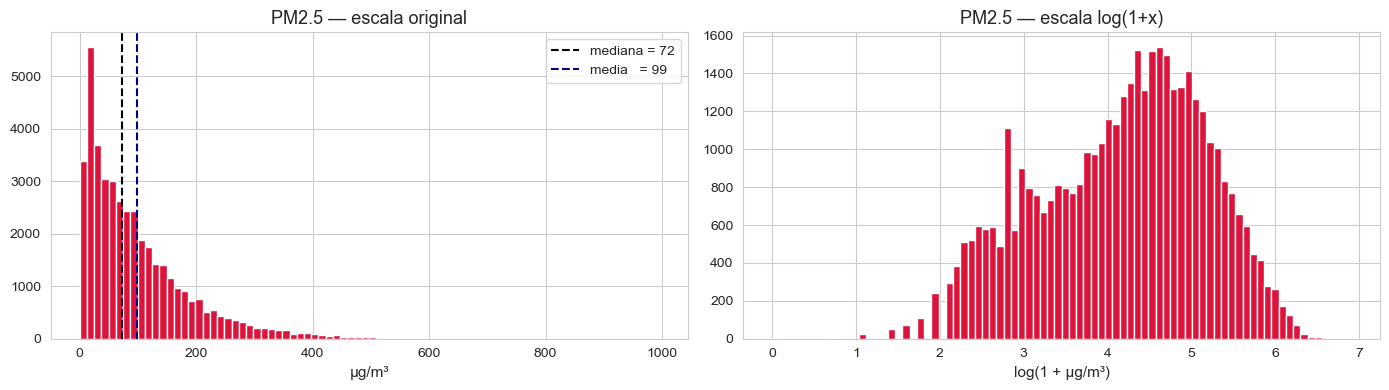

In [16]:
# Distribución detallada del target: pm2.5
# Mostramos también la versión log-transformada porque la variable está fuertemente sesgada a la derecha
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["pm2.5"].dropna(), bins=80, color="crimson", edgecolor="white")
axes[0].set_title("PM2.5 — escala original")
axes[0].set_xlabel("µg/m³")
axes[0].axvline(df["pm2.5"].median(), color="black", linestyle="--", label=f"mediana = {df['pm2.5'].median():.0f}")
axes[0].axvline(df["pm2.5"].mean(),   color="navy",  linestyle="--", label=f"media   = {df['pm2.5'].mean():.0f}")
axes[0].legend()

# log1p evita problemas con los ceros
axes[1].hist(np.log1p(df["pm2.5"].dropna()), bins=80, color="crimson", edgecolor="white")
axes[1].set_title("PM2.5 — escala log(1+x)")
axes[1].set_xlabel("log(1 + µg/m³)")

plt.tight_layout()
plt.show()

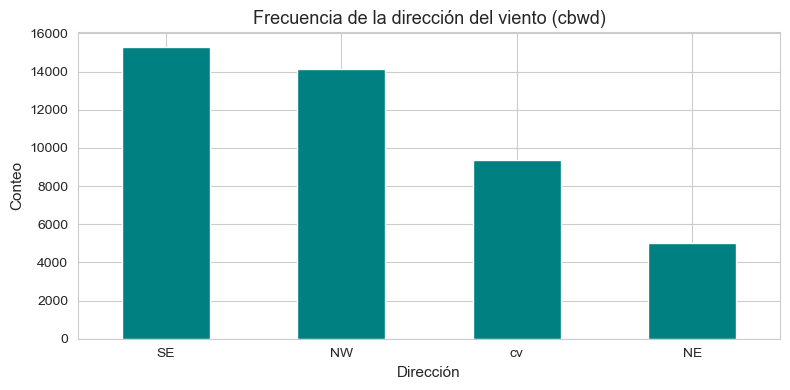

In [17]:
# Frecuencia de la dirección del viento
fig, ax = plt.subplots(figsize=(8, 4))
df["cbwd"].value_counts().plot(kind="bar", ax=ax, color="teal", edgecolor="white")
ax.set_title("Frecuencia de la dirección del viento (cbwd)")
ax.set_xlabel("Dirección")
ax.set_ylabel("Conteo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Variables numéricas**

**pm2.5:** La distribución de pm2.5 está fuertemente sesgada hacia la izquierda, ya que la mayoría de los valores son bajos, aunque existen algunos episodios con concentraciones muy altas de contaminación. Esto indica presencia de valores extremos y una distribución no normal.

**DEWP:** La variable DEWP presenta dos picos a lo largo de la distribución, lo que sugiere cambios en las condiciones de humedad y posibles efectos estacionales durante el periodo analizado.

**TEMP:** La temperatura muestra una distribución relativamente equilibrada, aunque con diferentes concentraciones de valores que reflejan variaciones climáticas entre estaciones del año.

**PRES:** La presión atmosférica tiene una distribución más estable y cercana a una forma normal, concentrándose principalmente entre 1000 y 1030 hPa, sin presencia marcada de valores extremos.

**Iws:** La variable Iws presenta una distribución asimétrica positiva, donde predominan velocidades de viento bajas y existen pocos casos de valores muy altos.

**Is:** La mayoría de los valores de Is son cero, indicando que los eventos de nieve son poco frecuentes dentro del conjunto de datos.

**Ir:** Similar a Is, la variable Ir concentra casi todos sus valores en cero, lo que sugiere que los eventos de lluvia intensa ocurren en pocas ocasiones.

**Variables categóricas:**

La variable cbwd muestra que las direcciones de viento más frecuentes son SE y NW, siendo SE la categoría predominante. La dirección cv(calm/variable) aparece con una frecuencia intermedia, mientras que NE es la menos común. Esto indica que el viento en la zona estudiada proviene principalmente del sureste y noroeste, lo que podría influir en la dispersión de contaminantes como el pm2.5.






## 5. Análisis bivariado



### Matriz de correlación

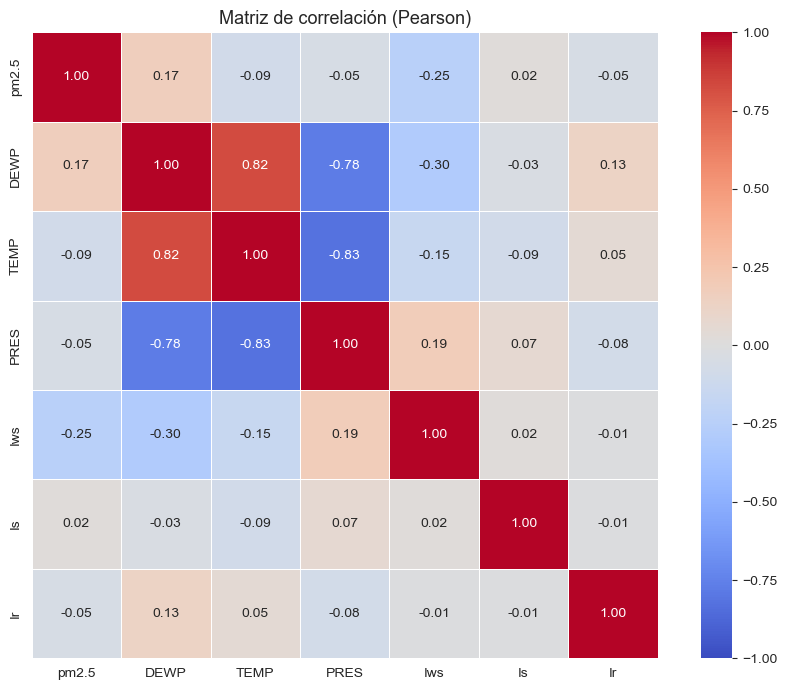

In [18]:
# Calcular la matriz de correlación solo sobre numéricas
corr = df[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

In [19]:
# Correlaciones específicamente contra el target ordenadas por magnitud absoluta
corr_target = df[variables_numericas].corr()["pm2.5"].drop("pm2.5")
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
print("Correlación de cada feature con pm2.5:")
print(corr_target.round(3))

Correlación de cada feature con pm2.5:
Iws    -0.248
DEWP    0.171
TEMP   -0.091
Ir     -0.051
PRES   -0.047
Is      0.019
Name: pm2.5, dtype: float64


Aunque las correlaciones lineales de Pearson entre PM2.5 y las variables meteorológicas (DEWP, TEMP, PRES, Iws, Is, Ir) son en general bajas, esto no implica necesariamente una falta de capacidad predictiva. La relación entre la concentración de material particulado y las condiciones meteorológicas suele ser no lineal, multivariable y con efectos rezagados (lags), los cuales no son capturados por una correlación bivariada simple.

En este sentido, las variables climáticas siguen siendo relevantes como predictores potenciales, ya que pueden aportar información significativa dentro de modelos más complejos (por ejemplo, modelos no lineales o con memoria temporal), donde su contribución conjunta y sus interacciones pueden explicar mejor la dinámica del PM2.5.

### PM2.5 vs variables continuas

Scatter plots para ver visualmente la forma de la relación (lineal, no lineal, ruido). Submuestreamos para que los gráficos sean legibles — con ~43k puntos el plot completo se vuelve una mancha.

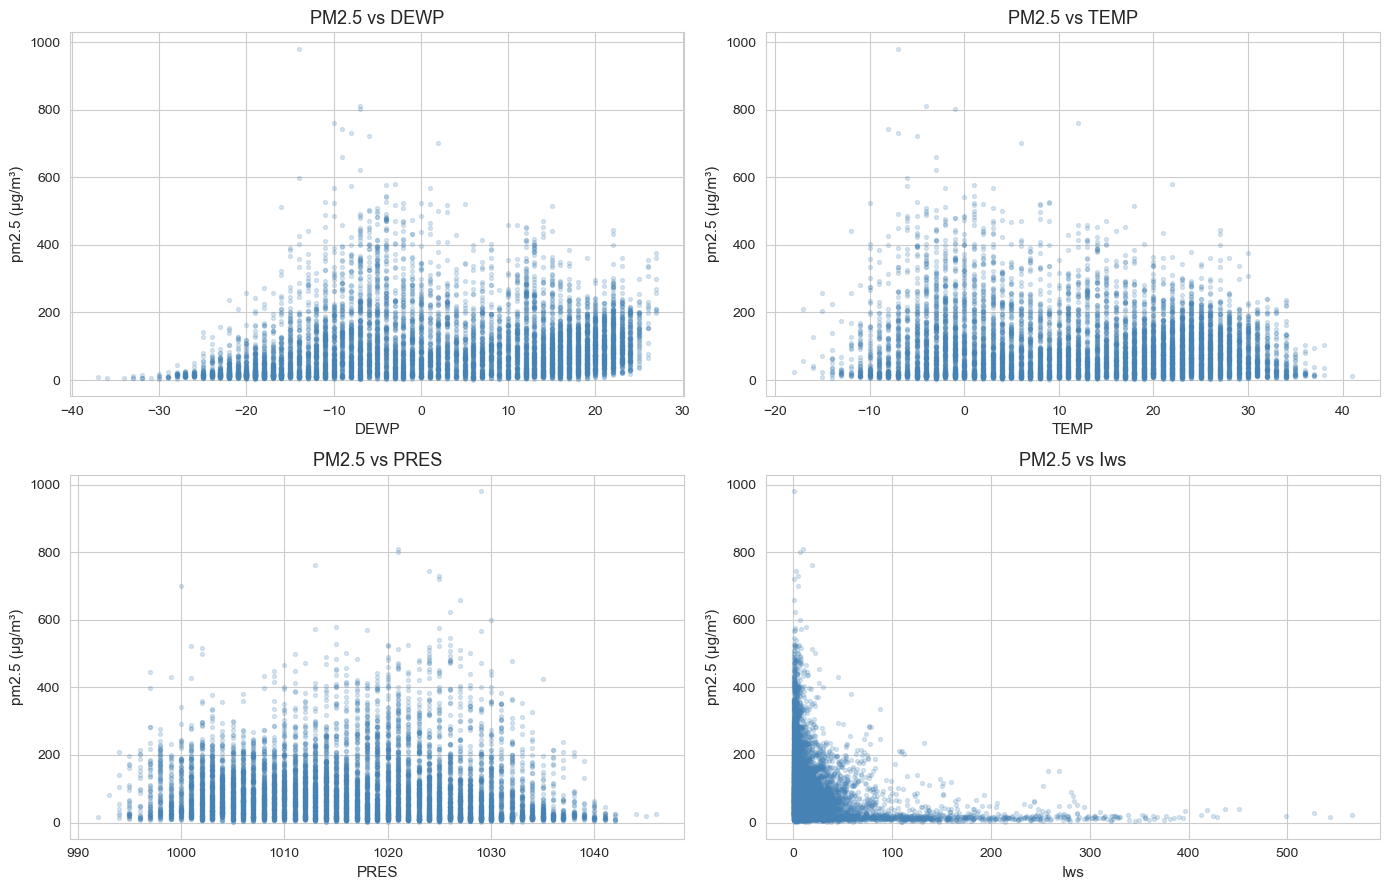

In [20]:
# Submuestreo aleatorio del 20% solo para visualización
df_sample = df.dropna(subset=["pm2.5"]).sample(frac=0.2, random_state=42)

features_continuas = ["DEWP", "TEMP", "PRES", "Iws"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(features_continuas):
    axes[i].scatter(df_sample[col], df_sample["pm2.5"], alpha=0.2, s=8, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("pm2.5 (µg/m³)")
    axes[i].set_title(f"PM2.5 vs {col}")

plt.tight_layout()
plt.show()

**DEWP, TEMP y PRES**

No hay tendencia lineal clara (consistente con Pearson bajo) pero sí se observa una estructura tipo “abanico” o envolvente, es decir hay rangos donde el PM2.5 puede ser alto o bajo.

La dispersión cambia con la variable → heterocedasticidad.
lo que sugiere que la variable no determina directamente el PM2.5, pero modula su variabilidad.

**Iws (velocidad del viento)**

Aquí sí hay un patrón claro, Relación inversa no lineal fuerte.
- A bajas velocidades → alta dispersión de PM2.5 (incluyendo valores extremos).
- A altas velocidades → PM2.5 bajo casi siempre.

Aunque la correlación lineal es baja (-0.25), existe una relación física clara de tipo no lineal: el viento actúa como mecanismo de dispersión, limitando concentraciones altas.


En consecuencia, estas variables no deben descartarse como predictoras, ya que su aporte puede ser significativo en modelos no lineales o que consideren efectos combinados y dependencias temporales. Estos resultados justifican el uso de modelos como XGBoost, capaces de capturar relaciones no lineales y efectos de interacción que no son evidentes en análisis bivariados.

### PM2.5 vs variable categórica (dirección del viento)

La dirección del viento es uno de los factores más relevantes en la calidad del aire de Beijing — el viento del NW suele traer aire limpio desde Mongolia, mientras que los vientos del SE traen contaminación de las zonas industriales del sur.

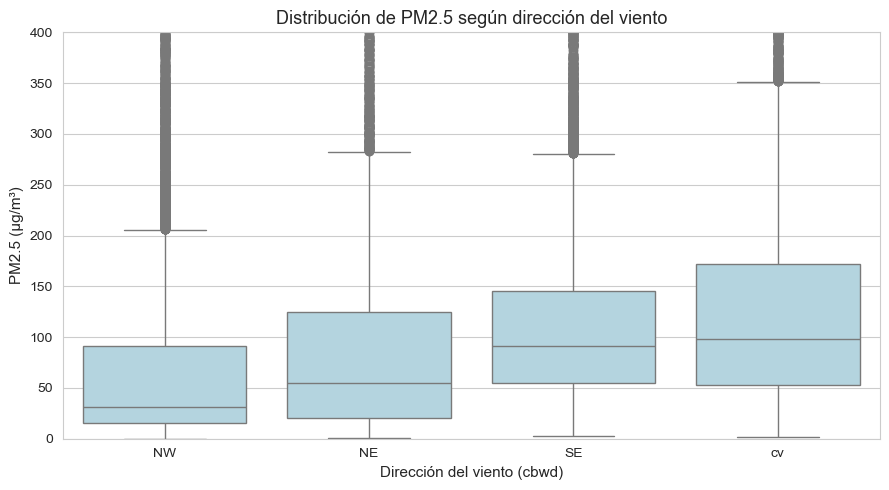

,count,mean,median,std
cbwd,,,,
NE,4756,90.2,55.0,95.2
NW,13484,70.1,31.0,89.1
SE,14573,110.8,91.0,80.1
cv,8944,126.2,98.0,100.4


In [21]:
# Boxplot de PM2.5 por dirección del viento
fig, ax = plt.subplots(figsize=(9, 5))
orden = df.groupby("cbwd")["pm2.5"].median().sort_values().index
sns.boxplot(data=df, x="cbwd", y="pm2.5", order=orden, ax=ax, color="lightblue")
ax.set_title("Distribución de PM2.5 según dirección del viento")
ax.set_xlabel("Dirección del viento (cbwd)")
ax.set_ylabel("PM2.5 (µg/m³)")
# Limitar eje y para que los outliers no aplasten la caja
ax.set_ylim(0, 400)
plt.tight_layout()
plt.show()

# Estadísticas numéricas por dirección
df.groupby("cbwd")["pm2.5"].agg(["count", "mean", "median", "std"]).round(1)

El análisis de la distribución de PM2.5 en función de la dirección del viento evidencia diferencias sistemáticas entre categorías, con variaciones tanto en la mediana como en la dispersión de las concentraciones. En particular, ciertas direcciones (e.g., SE y cv) presentan mayores niveles y variabilidad de PM2.5, mientras que otras (e.g., NW) se asocian a concentraciones más bajas.

Estos resultados sugieren la influencia de patrones de transporte atmosférico y la posible presencia de fuentes emisoras dominantes en direcciones específicas. En consecuencia, la dirección del viento constituye una variable categórica relevante que puede aportar capacidad predictiva significativa en modelos de calidad del aire, especialmente en combinación con otras variables meteorológicas.

## 6. Análisis temporal



Al ser una serie temporal, conviene mirar tendencias y estacionalidad a varias escalas: anual, mensual, día de la semana y hora del día. Esto orientará el feature engineering temporal (variables cíclicas, lags, medias móviles, etc.).

Se examina la evolución temporal de PM2.5 a lo largo de los 5 años mediante una serie temporal que combina valores horarios (en gris claro) con una media móvil de 7 días (en rojo) para visualizar tendencias de fondo sin ruido de corto plazo.

Posteriormente, se crean columnas auxiliares (año, mes, día de semana, hora) para descomponer la variabilidad de PM2.5 en sus componentes estacionales. Se generan cuatro visualizaciones complementarias:

**Estacionalidad mensual:** Gráfico de barras mostrando el promedio de PM2.5 por mes, permitiendo identificar picos en invierno (cuando aumenta la calefacción y se reduce la dispersión de contaminantes) y mínimos en verano.

**Patrón diario (por hora):** Gráfico de línea que revela cómo varía PM2.5 a lo largo de las 24 horas del día, reflejando efectos del tráfico vehicular, actividad industrial y cambios en la capa límite atmosférica.

**Comparación interanual:** Líneas por año superpuestas en función del mes, permitiendo evaluar si la calidad del aire ha mejorado, empeorado o permanecido estable entre 2010 y 2014.

**Heatmap mes × hora:** Matriz de calor que integra simultáneamente ambas estacionalidades (mensual y diaria), identificando las combinaciones de período y hora con mayor contaminación.

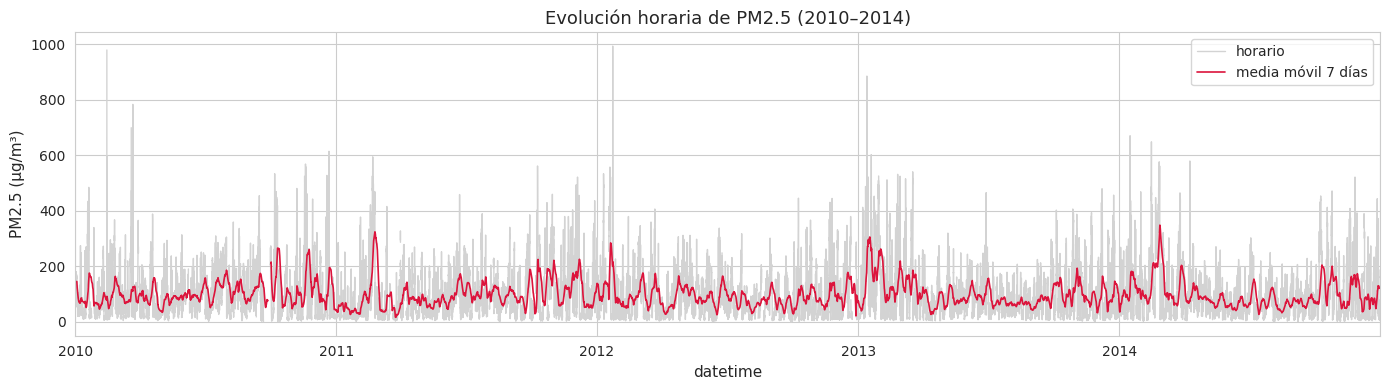

In [36]:
# Serie temporal completa con suavizado (media móvil de 7 días) para ver la tendencia
fig, ax = plt.subplots(figsize=(14, 4))
df["pm2.5"].plot(ax=ax, color="lightgray", lw=1, label="horario")
df["pm2.5"].rolling(window=24*7, min_periods=24).mean().plot(
    ax=ax, color="crimson", lw=1.2, label="media móvil 7 días"
)
ax.set_title("Evolución horaria de PM2.5 (2010–2014)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Crear columnas auxiliares de fecha para el análisis estacional
df_t = df.copy()
df_t["year"]    = df_t.index.year
df_t["month"]   = df_t.index.month
df_t["weekday"] = df_t.index.dayofweek    # 0=lunes, 6=domingo
df_t["hour"]    = df_t.index.hour

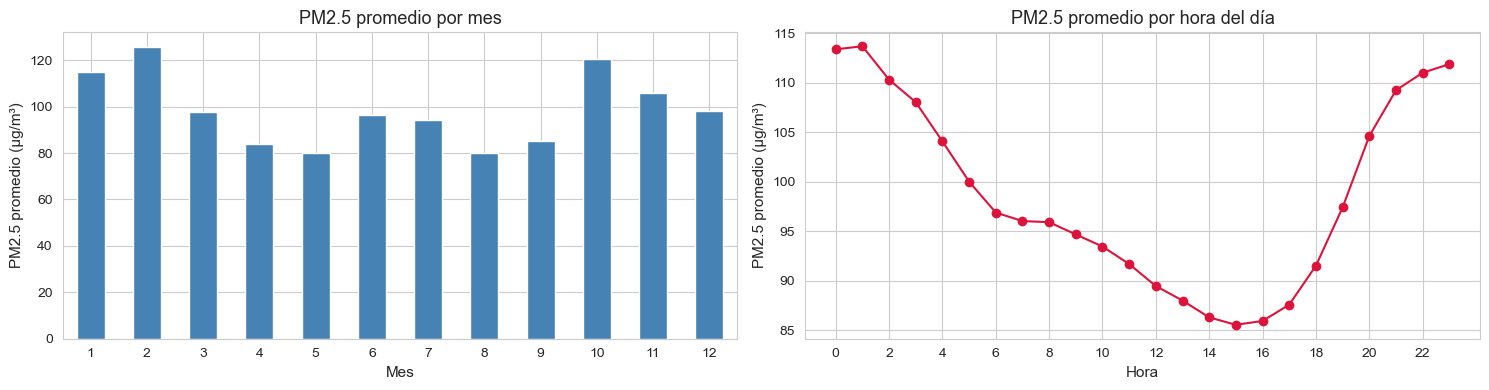

In [24]:
# Estacionalidad por mes y por hora del día
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Por mes — esperamos picos en invierno (calefacción con carbón) y mínimos en verano
df_t.groupby("month")["pm2.5"].mean().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("PM2.5 promedio por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("PM2.5 promedio (µg/m³)")
axes[0].set_xticklabels(range(1, 13), rotation=0)

# Por hora del día — esperamos patrón ligado a tráfico y a la capa límite atmosférica
df_t.groupby("hour")["pm2.5"].mean().plot(
    kind="line", ax=axes[1], color="crimson", marker="o"
)
axes[1].set_title("PM2.5 promedio por hora del día")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("PM2.5 promedio (µg/m³)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

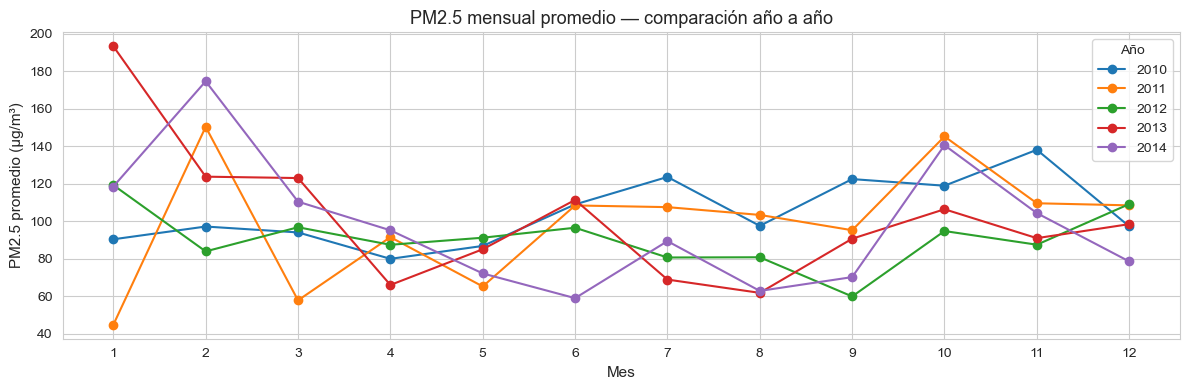

In [25]:
# Comparación año contra año — ¿hubo mejora o empeoramiento de la calidad del aire?
fig, ax = plt.subplots(figsize=(12, 4))
df_t.groupby(["year", "month"])["pm2.5"].mean().unstack("year").plot(ax=ax, marker="o")
ax.set_title("PM2.5 mensual promedio — comparación año a año")
ax.set_xlabel("Mes")
ax.set_ylabel("PM2.5 promedio (µg/m³)")
ax.set_xticks(range(1, 13))
ax.legend(title="Año")
plt.tight_layout()
plt.show()

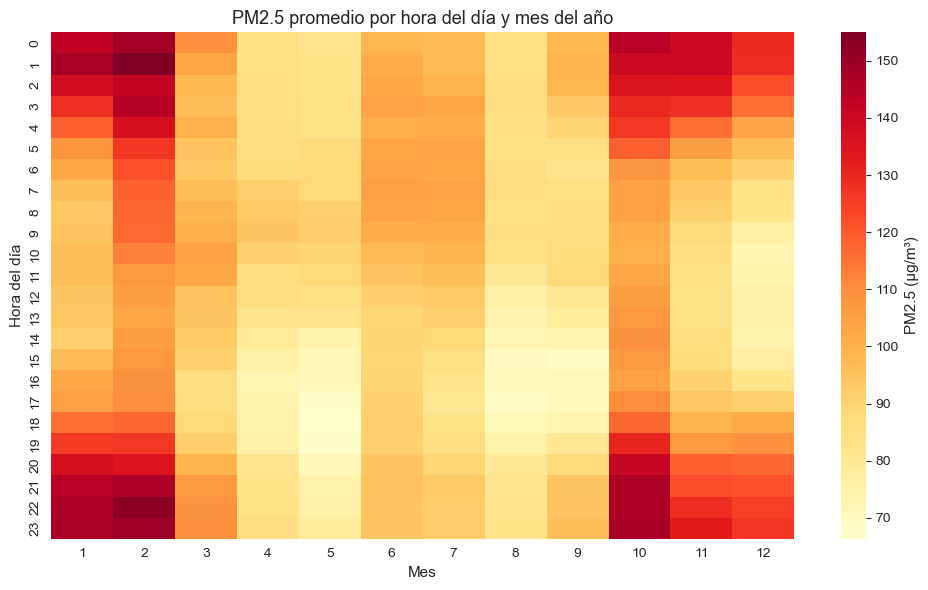

In [26]:
# Heatmap mes × hora — útil para ver simultáneamente las dos estacionalidades dominantes
pivot = df_t.pivot_table(values="pm2.5", index="hour", columns="month", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "PM2.5 (µg/m³)"})
ax.set_title("PM2.5 promedio por hora del día y mes del año")
ax.set_xlabel("Mes")
ax.set_ylabel("Hora del día")
plt.tight_layout()
plt.show()

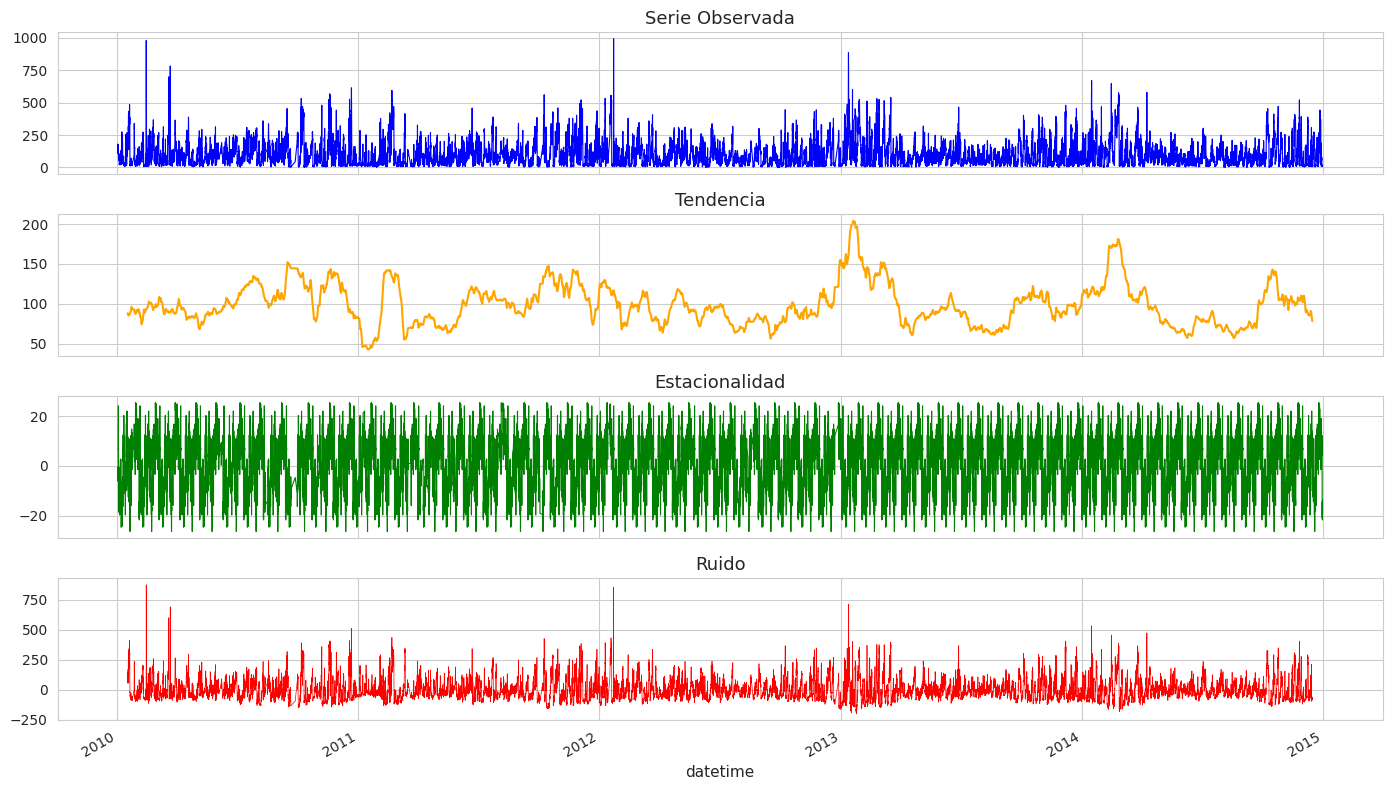

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Descomponer la serie
result = seasonal_decompose(df["pm2.5"].dropna(), model='additive', period=24*30)

# Graficar los componentes
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

result.observed.plot(ax=ax1, title='Serie Observada', color='blue', lw=0.8)
result.trend.plot(ax=ax2, title='Tendencia', color='orange', lw=1.5)
result.seasonal.plot(ax=ax3, title='Estacionalidad', color='green', lw=0.8)
result.resid.plot(ax=ax4, title='Ruido', color='red', lw=0.5)

plt.tight_layout()
plt.show()

La descomposición de la serie temporal de PM2.5 evidencia que el proceso presenta una estructura compleja compuesta por una tendencia no estacionaria, una componente estacional bien definida y un componente residual con alta variabilidad. La estacionalidad persistente sugiere la influencia de ciclos periódicos asociados a condiciones meteorológicas y patrones de actividad antrópica.

Adicionalmente, la presencia de picos en el componente residual indica la ocurrencia de eventos extremos que no son completamente capturados por componentes lineales y aditivos, lo que refuerza la hipótesis de dinámicas no lineales y dependencias temporales.

En conjunto, estos resultados indican que la modelación del PM2.5 requiere enfoques capaces de capturar simultáneamente tendencia, estacionalidad y relaciones no lineales, justificando el uso de modelos avanzados de tipo no lineal y con memoria temporal.

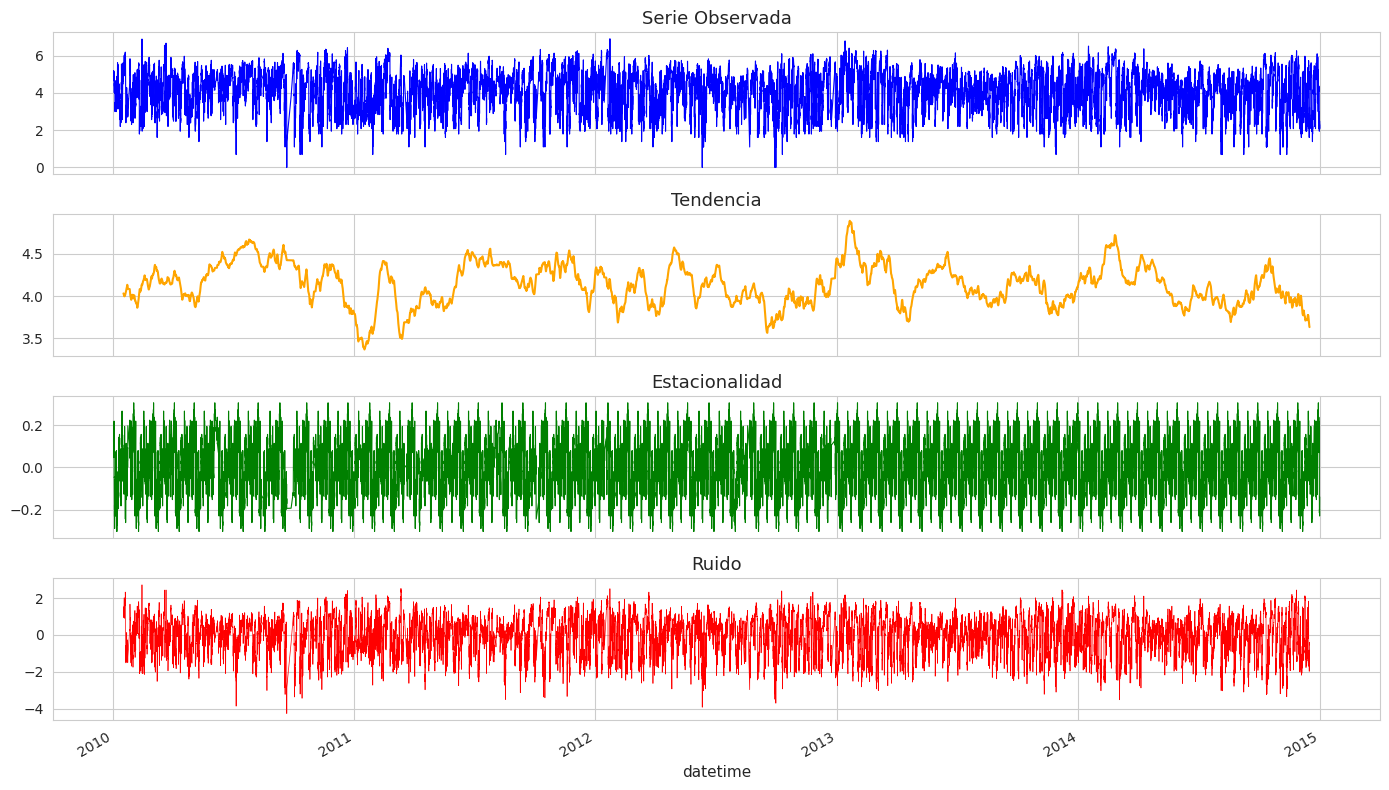

In [47]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Descomponer la serie
result = seasonal_decompose(
    np.log(df["pm2.5"].replace(0, np.nan).dropna()),
    model='additive',
    period=24*30
)
# Graficar los componentes
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

result.observed.plot(ax=ax1, title='Serie Observada', color='blue', lw=0.8)
result.trend.plot(ax=ax2, title='Tendencia', color='orange', lw=1.5)
result.seasonal.plot(ax=ax3, title='Estacionalidad', color='green', lw=0.8)
result.resid.plot(ax=ax4, title='Ruido', color='red', lw=0.5)

plt.tight_layout()
plt.show()

La transformación logarítmica de la serie de PM2.5 permite estabilizar la varianza y representar adecuadamente la naturaleza multiplicativa del proceso. En esta nueva escala, la descomposición revela una tendencia más suave, una componente estacional claramente definida y un residuo con comportamiento más cercano a un proceso estacionario.

Estos resultados indican que la dinámica del PM2.5 presenta una dependencia entre el nivel de la serie y su variabilidad, lo cual no es capturado adecuadamente mediante un modelo aditivo en la escala original. En consecuencia, el análisis en escala logarítmica resulta más apropiado para la modelación, al reflejar de mejor manera la estructura temporal subyacente del proceso.

## 7. Detección de outliers

Boxplots para localizar outliers en cada variable numérica. Estos son en los que hizo mucho enfasis el profesor.
En este dataset los "outliers" altos de PM2.5 son **reales** (corresponden a episodios de smog severo) — no se deben eliminar a la ligera, pero sí conviene tener en mente la transformación logarítmica o modelos robustos.

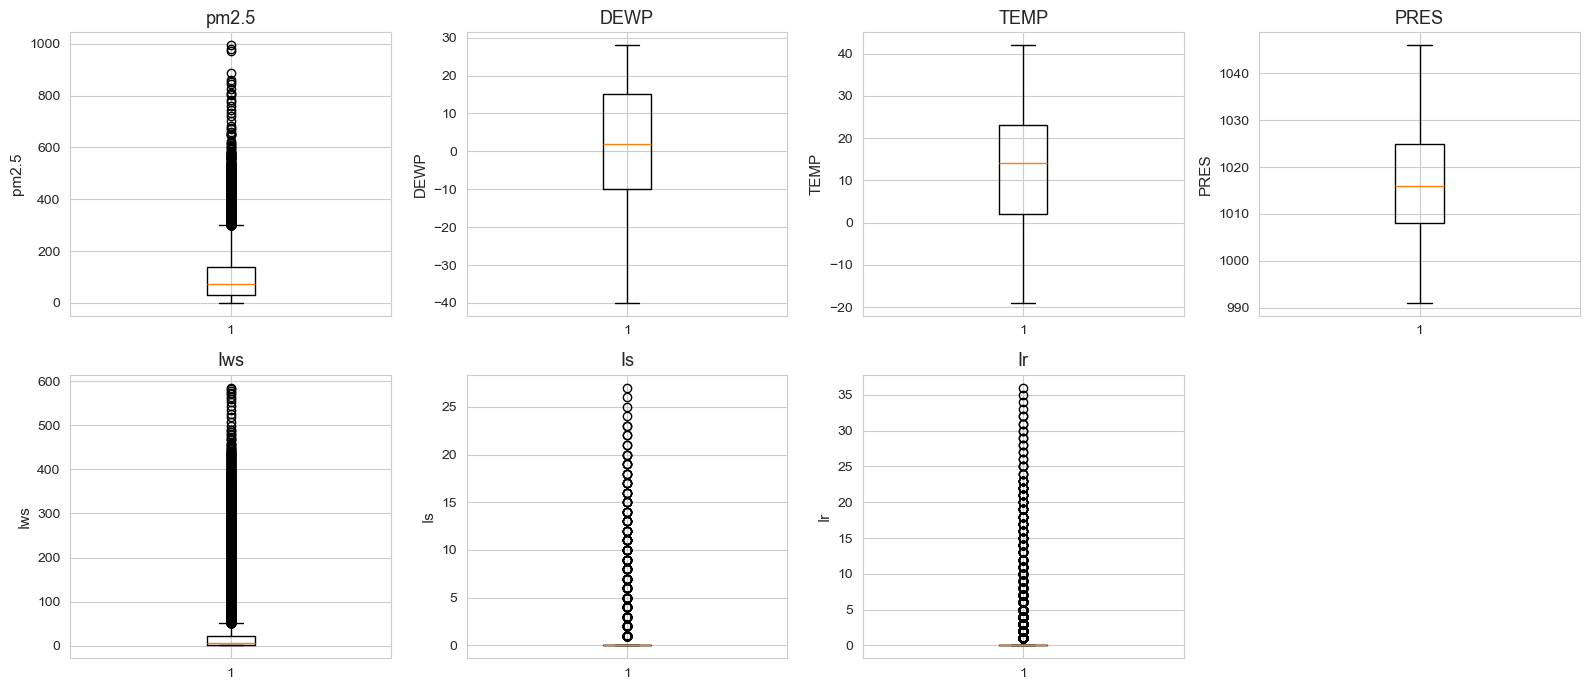

In [27]:
# Boxplots de las variables numéricas
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

# Ocultar el último subplot vacío
for j in range(len(variables_numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Cuantificar outliers con la regla de Tukey (1.5 * IQR)
def contar_outliers_iqr(serie):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < bajo) | (s > alto)).sum()
    return pd.Series({"n_outliers": n_out, "% outliers": round(100 * n_out / len(s), 2),
                      "limite_inf": round(bajo, 2), "limite_sup": round(alto, 2)})

tabla_out = pd.DataFrame({col: contar_outliers_iqr(df[col]) for col in variables_numericas}).T
tabla_out

,n_outliers,% outliers,limite_inf,limite_sup
pm2.5,1773.0,4.25,-133.00,299.00
DEWP,0.0,0.00,-47.50,52.50
TEMP,0.0,0.00,-29.50,54.50
PRES,0.0,0.00,982.50,1050.50
Iws,5101.0,11.64,-28.39,52.09
Is,368.0,0.84,0.00,0.00
Ir,1808.0,4.13,0.00,0.00


## 11. Conclusiones del EDA y recomendaciones para modelado

### Qué encontramos

- **Tamaño**: ~43,800 registros horarios sobre 5 años (cobertura completa del rango temporal).
- **Calidad**: la única variable con nulos significativos es el **target `pm2.5`** (~5%). El resto está completo.
- **Distribución del target**: muy **sesgada a la derecha**, con cola larga hacia valores extremos (>500 µg/m³) en episodios de smog. La transformación `log(1+x)` la normaliza notablemente.
- **Correlaciones lineales con el target**: moderadas y todas en magnitudes pequeñas — la más fuerte es `Iws` (velocidad acumulada del viento) en sentido negativo (más viento → menos PM2.5), seguida de `DEWP`, `PRES` y `TEMP`. Esto sugiere que las relaciones son **no lineales** y modelos como Random Forest, XGBoost o redes neuronales tendrán ventaja sobre regresión lineal.
- **Estacionalidad clara**: niveles más altos en **invierno** (calefacción con carbón) y más bajos en verano; perfil horario con doble pico en mañana/noche.
- **Dirección del viento**: el viento del **NW** trae aire limpio, los vientos `cv` (calma) y del SE coinciden con los peores niveles. Variable categórica con poder predictivo claro.
- **Outliers**: el ~7% de las observaciones de PM2.5 caen fuera del IQR, pero son **eventos reales** (no errores de medición).

### Recomendaciones para la fase de modelado (ML/DL)

**Limpieza e imputación**
- Para los nulos de `pm2.5`: como es el target, lo más limpio es **eliminar esas filas** del set de entrenamiento (no se puede entrenar sin etiqueta). Si se quisiera predecirlos, sería un problema separado de imputación.
- Verificar que no queden gaps al construir variables de lag.

**Feature engineering**
- Codificar `cbwd` con one-hot encoding (4 categorías).
- Codificar `hour` y `month` como variables **cíclicas** con seno/coseno (`sin(2π·hora/24)`, `cos(2π·hora/24)`) en lugar de ordinales.
- Crear **lags** del target (`pm2.5_t-1`, `pm2.5_t-24`, etc.) para modelos de series temporales.
- Considerar **medias móviles** y diferencias (`Iws_diff`) como features adicionales.

**Transformaciones**
- Aplicar `log(1+x)` al target para entrenamiento (revertir con `expm1` para evaluar).
- Estandarizar (`StandardScaler`) las variables continuas para modelos sensibles a escala (redes neuronales, SVM, KNN).

**Validación**
- **No usar K-Fold aleatorio**: es serie temporal, hay que usar split cronológico (`TimeSeriesSplit` de sklearn) o un walk-forward para no contaminar el entrenamiento con información futura.

**Modelos sugeridos como punto de partida**
1. Línea base: regresión lineal o `Ridge` con feature engineering.
2. **Gradient Boosting** (`XGBoost`, `LightGBM`) — suele ser el ganador en datasets tabulares con relaciones no lineales.
3. **LSTM / GRU** o **Temporal Fusion Transformer** si se quiere explotar la estructura temporal pura.

**Métrica**
- RMSE o MAE en escala original; reportar también MAPE con cuidado (puede explotar cerca de cero).

---

Con esto, los datos ya están entendidos y listos para pasar a las etapas de **preprocesamiento → entrenamiento → evaluación → tuning**.